In [1]:
import torch

import torch.nn as nn

import torch.optim as optim

from torchvision import datasets, transforms

from torch.utils.data import DataLoader, random_split



import matplotlib.pyplot as plt

# Normalization techniques

In [2]:
# define transformations for the data

transform = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize((0.1307,), (0.3081,))  # mean and standard deviation for MNIST

])



# download the complete MNIST data set

full_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)



# split the data set into training and validation

train_size = int(0.8 * len(full_dataset))

val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])



# create a test data set

test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)



# determine the batch size

batch_size = 64



# create data loaders

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)



print(f"Train set size: {len(train_dataset)}")

print(f"Validation set size: {len(val_dataset)}")

print(f"Test set size: {len(test_dataset)}")

print(f"Number of batches in train_loader: {len(train_loader)}")

Failed to download (trying next):
<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1007)>



100%|██████████| 9912422/9912422 [00:00<00:00, 39796985.00it/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1007)>



100%|██████████| 28881/28881 [00:00<00:00, 1032312.63it/s]

Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw



Failed to download (trying next):
<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1007)>



100%|██████████| 1648877/1648877 [00:00<00:00, 9064493.65it/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1007)>



100%|██████████| 4542/4542 [00:00<00:00, 3558850.88it/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw

Train set size: 48000
Validation set size: 12000
Test set size: 10000
Number of batches in train_loader: 750


In [3]:
class Net(nn.Module):

    def __init__(self):

        super(Net, self).__init__()

        self.fc1 = nn.Linear(784, 512)

        self.fc2 = nn.Linear(512, 512)

        self.fc3 = nn.Linear(512, 10)



    def forward(self, x):

        x = torch.relu(self.fc1(x))

        x = torch.relu(self.fc2(x))

        return self.fc3(x)

In [4]:
# no regularization



model = Net()

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters())



num_epochs = 20



train_losses = []

train_accs = []



val_losses = []

val_accs = []



for epoch in range(num_epochs):

    model.train()

    train_loss = 0

    train_correct = 0

    train_total = 0



    for batch_idx, (data, target) in enumerate(train_loader):

        optimizer.zero_grad()

        output = model(data.view(data.size(0), -1))

        loss = criterion(output, target)

        loss.backward()

        optimizer.step()



        train_loss += loss.item()

        _, predicted = output.max(1)

        train_total += target.size(0)

        train_correct += predicted.eq(target).sum().item()



    train_loss /= len(train_loader)

    train_accuracy = 100. * train_correct / train_total

    

    train_losses.append(train_loss)

    train_accs.append(train_accuracy)



    # validation step

    model.eval()

    val_loss = 0

    val_correct = 0

    val_total = 0



    with torch.no_grad():

        for data, target in val_loader:

            output = model(data.view(data.size(0), -1))

            loss = criterion(output, target)

            val_loss += loss.item()

            _, predicted = output.max(1)

            val_total += target.size(0)

            val_correct += predicted.eq(target).sum().item()



    val_loss /= len(val_loader)

    val_accuracy = 100. * val_correct / val_total

    

    val_losses.append(val_loss)

    val_accs.append(val_accuracy)



    print(f'Epoch [{epoch+1}/{num_epochs}]')

    print(f'Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%')

    print(f'Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%')

    print('-' * 50)

Epoch [1/20]
Train Loss: 0.2219, Train Accuracy: 93.14%
Val Loss: 0.1088, Val Accuracy: 96.52%
--------------------------------------------------
Epoch [2/20]
Train Loss: 0.0971, Train Accuracy: 96.91%
Val Loss: 0.0871, Val Accuracy: 97.27%
--------------------------------------------------
Epoch [3/20]
Train Loss: 0.0694, Train Accuracy: 97.79%
Val Loss: 0.0779, Val Accuracy: 97.53%
--------------------------------------------------
Epoch [4/20]
Train Loss: 0.0521, Train Accuracy: 98.30%
Val Loss: 0.0954, Val Accuracy: 97.16%
--------------------------------------------------
Epoch [5/20]
Train Loss: 0.0424, Train Accuracy: 98.67%
Val Loss: 0.0872, Val Accuracy: 97.59%
--------------------------------------------------
Epoch [6/20]
Train Loss: 0.0318, Train Accuracy: 98.98%
Val Loss: 0.0908, Val Accuracy: 97.72%
--------------------------------------------------
Epoch [7/20]
Train Loss: 0.0308, Train Accuracy: 99.06%
Val Loss: 0.1051, Val Accuracy: 97.38%
-----------------------------

In [5]:
def visualize_training_history(train_losses, train_accs, val_losses, val_accs):

    epochs = range(1, len(train_losses) + 1)



    plt.figure(figsize=(12, 5))



    # loss plot

    plt.subplot(1, 2, 1)

    plt.plot(epochs, train_losses, 'b-', label='Train Loss')

    plt.plot(epochs, val_losses, 'r-', label='Validation Loss')

    plt.title('Training and Validation Loss')

    plt.xlabel('Epochs')

    plt.ylabel('Loss')

    plt.legend()



    # accuracy plot

    plt.subplot(1, 2, 2)

    plt.plot(epochs, train_accs, 'b-', label='Train Accuracy')

    plt.plot(epochs, val_accs, 'r-', label='Validation Accuracy')

    plt.title('Training and Validation Accuracy')

    plt.xlabel('Epochs')

    plt.ylabel('Accuracy')

    plt.legend()



    plt.tight_layout()

    plt.show()

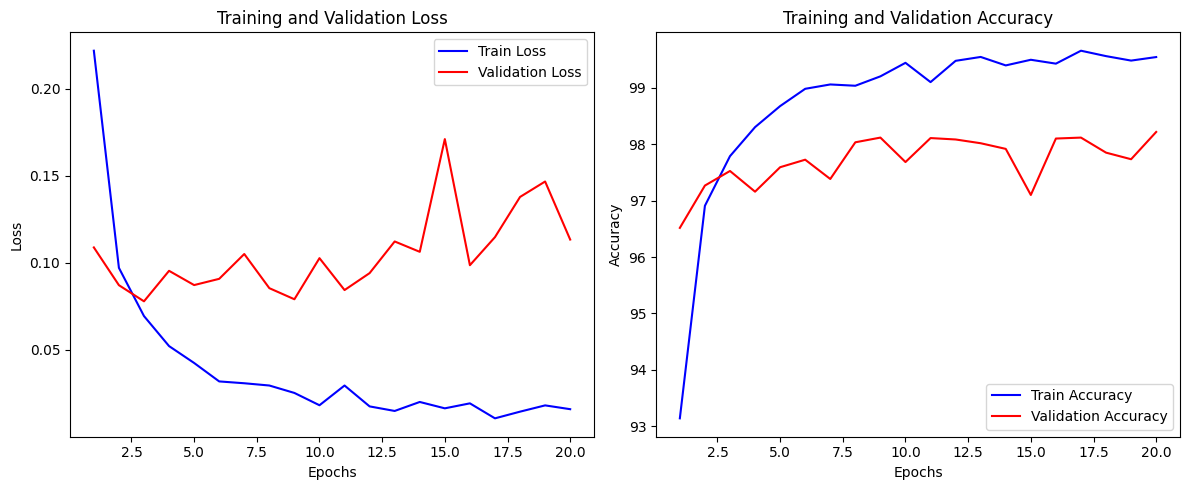

In [6]:
visualize_training_history(train_losses, train_accs, val_losses, val_accs)

Epoch [1/20]
Train Loss: 0.2290, Train Accuracy: 93.00%
Val Loss: 0.1247, Val Accuracy: 95.97%
--------------------------------------------------
Epoch [2/20]
Train Loss: 0.1137, Train Accuracy: 96.44%
Val Loss: 0.1153, Val Accuracy: 96.38%
--------------------------------------------------
Epoch [3/20]
Train Loss: 0.0971, Train Accuracy: 96.94%
Val Loss: 0.0953, Val Accuracy: 96.98%
--------------------------------------------------
Epoch [4/20]
Train Loss: 0.0808, Train Accuracy: 97.49%
Val Loss: 0.0927, Val Accuracy: 97.08%
--------------------------------------------------
Epoch [5/20]
Train Loss: 0.0761, Train Accuracy: 97.59%
Val Loss: 0.0840, Val Accuracy: 97.47%
--------------------------------------------------
Epoch [6/20]
Train Loss: 0.0678, Train Accuracy: 97.88%
Val Loss: 0.0917, Val Accuracy: 97.09%
--------------------------------------------------
Epoch [7/20]
Train Loss: 0.0650, Train Accuracy: 97.93%
Val Loss: 0.0801, Val Accuracy: 97.41%
-----------------------------

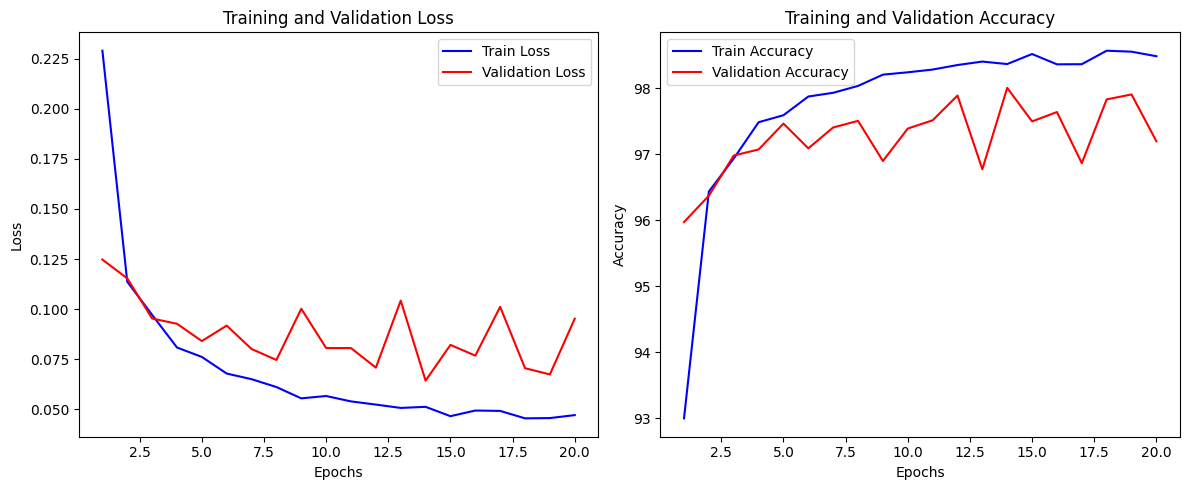

In [7]:
# L2 regularization



model = Net()

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), weight_decay=1e-3)



num_epochs = 20



train_losses = []

train_accs = []



val_losses = []

val_accs = []



for epoch in range(num_epochs):

    model.train()

    train_loss = 0

    train_correct = 0

    train_total = 0



    for batch_idx, (data, target) in enumerate(train_loader):

        optimizer.zero_grad()

        output = model(data.view(data.size(0), -1))

        loss = criterion(output, target)

        loss.backward()

        optimizer.step()



        train_loss += loss.item()

        _, predicted = output.max(1)

        train_total += target.size(0)

        train_correct += predicted.eq(target).sum().item()



    train_loss /= len(train_loader)

    train_accuracy = 100. * train_correct / train_total

    

    train_losses.append(train_loss)

    train_accs.append(train_accuracy)



    # validation step

    model.eval()

    val_loss = 0

    val_correct = 0

    val_total = 0



    with torch.no_grad():

        for data, target in val_loader:

            output = model(data.view(data.size(0), -1))

            loss = criterion(output, target)

            val_loss += loss.item()

            _, predicted = output.max(1)

            val_total += target.size(0)

            val_correct += predicted.eq(target).sum().item()



    val_loss /= len(val_loader)

    val_accuracy = 100. * val_correct / val_total

    

    val_losses.append(val_loss)

    val_accs.append(val_accuracy)



    print(f'Epoch [{epoch+1}/{num_epochs}]')

    print(f'Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%')

    print(f'Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%')

    print('-' * 50)

    

visualize_training_history(train_losses, train_accs, val_losses, val_accs)

In [8]:
# early stopping



model = Net()

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters())

best_val_loss = float('inf')

patience = 2

counter = 0



train_losses = []

train_accs = []

val_losses = []

val_accs = []



for epoch in range(20):

    model.train()

    train_loss = 0

    train_correct = 0

    train_total = 0

    for batch_idx, (data, target) in enumerate(train_loader):

        optimizer.zero_grad()

        output = model(data.view(data.size(0), -1))

        loss = criterion(output, target)

        loss.backward()

        optimizer.step()

        

        train_loss += loss.item()

        _, predicted = output.max(1)

        train_total += target.size(0)

        train_correct += predicted.eq(target).sum().item()

    

    train_loss /= len(train_loader)

    train_acc = 100. * train_correct / train_total

    

    model.eval()

    val_loss = 0

    val_correct = 0

    val_total = 0

    with torch.no_grad():

        for data, target in val_loader:

            output = model(data.view(data.size(0), -1))

            val_loss += criterion(output, target).item()

            _, predicted = output.max(1)

            val_total += target.size(0)

            val_correct += predicted.eq(target).sum().item()

    

    val_loss /= len(val_loader)

    val_acc = 100. * val_correct / val_total

    

    # save results

    train_losses.append(train_loss)

    train_accs.append(train_acc)

    val_losses.append(val_loss)

    val_accs.append(val_acc)

    

    print(f'Epoch {epoch}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, '

          f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

    

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        counter = 0

    else:

        counter += 1

        if counter >= patience:

            print(f"Early stopping at epoch {epoch}")

            break

Epoch 0: Train Loss: 0.2268, Train Acc: 93.12%, Val Loss: 0.1128, Val Acc: 96.56%
Epoch 1: Train Loss: 0.0962, Train Acc: 97.02%, Val Loss: 0.0809, Val Acc: 97.32%
Epoch 2: Train Loss: 0.0652, Train Acc: 98.04%, Val Loss: 0.0840, Val Acc: 97.45%
Epoch 3: Train Loss: 0.0502, Train Acc: 98.36%, Val Loss: 0.0978, Val Acc: 96.78%
Early stopping at epoch 3


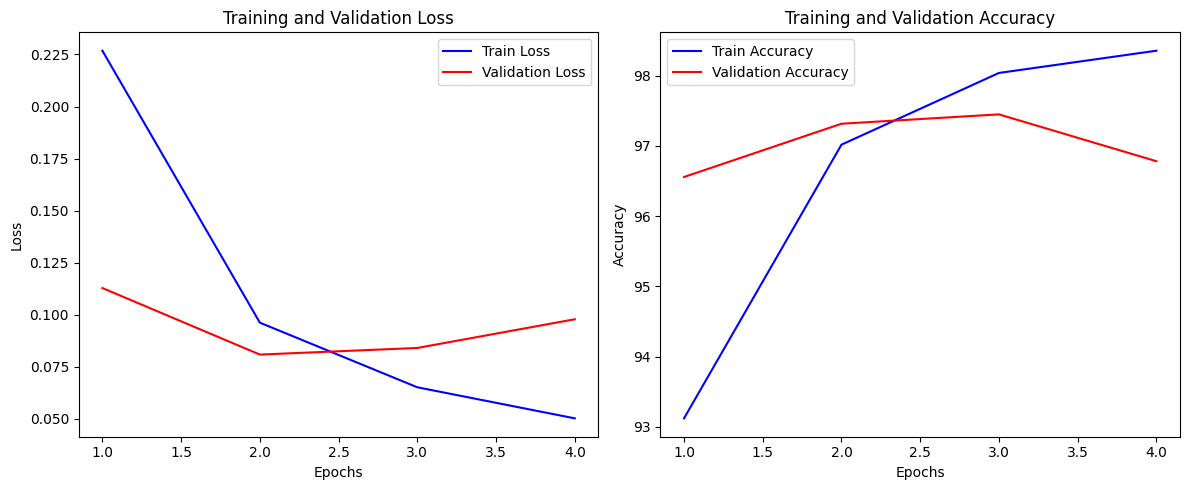

In [9]:
visualize_training_history(train_losses, train_accs, val_losses, val_accs)

In [10]:
class NetWithDropout(nn.Module):

    def __init__(self):

        super(NetWithDropout, self).__init__()

        self.fc1 = nn.Linear(784, 512)

        self.dropout1 = nn.Dropout(0.2)

        self.fc2 = nn.Linear(512, 512)

        self.dropout2 = nn.Dropout(0.2)

        self.fc3 = nn.Linear(512, 10)



    def forward(self, x):

        x = torch.relu(self.fc1(x))

        x = self.dropout1(x)

        x = torch.relu(self.fc2(x))

        x = self.dropout2(x)

        return self.fc3(x)

In [11]:
# dropout



model = NetWithDropout()

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters())



train_losses = []

train_accs = []

val_losses = []

val_accs = []



for epoch in range(20):

    model.train()

    train_loss = 0

    train_correct = 0

    train_total = 0

    for batch_idx, (data, target) in enumerate(train_loader):

        optimizer.zero_grad()

        output = model(data.view(data.size(0), -1))

        loss = criterion(output, target)

        loss.backward()

        optimizer.step()

        

        train_loss += loss.item()

        _, predicted = output.max(1)

        train_total += target.size(0)

        train_correct += predicted.eq(target).sum().item()

    

    train_loss /= len(train_loader)

    train_acc = 100. * train_correct / train_total

    

    model.eval()

    val_loss = 0

    val_correct = 0

    val_total = 0

    with torch.no_grad():

        for data, target in val_loader:

            output = model(data.view(data.size(0), -1))

            val_loss += criterion(output, target).item()

            _, predicted = output.max(1)

            val_total += target.size(0)

            val_correct += predicted.eq(target).sum().item()

    

    val_loss /= len(val_loader)

    val_acc = 100. * val_correct / val_total

    

    # save results

    train_losses.append(train_loss)

    train_accs.append(train_acc)

    val_losses.append(val_loss)

    val_accs.append(val_acc)

    

    print(f'Epoch {epoch}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, '

          f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

Epoch 0: Train Loss: 0.2533, Train Acc: 92.24%, Val Loss: 0.1264, Val Acc: 95.88%
Epoch 1: Train Loss: 0.1228, Train Acc: 96.23%, Val Loss: 0.1050, Val Acc: 96.62%
Epoch 2: Train Loss: 0.0958, Train Acc: 97.02%, Val Loss: 0.0857, Val Acc: 97.31%
Epoch 3: Train Loss: 0.0796, Train Acc: 97.47%, Val Loss: 0.0692, Val Acc: 97.81%
Epoch 4: Train Loss: 0.0671, Train Acc: 97.90%, Val Loss: 0.0821, Val Acc: 97.55%
Epoch 5: Train Loss: 0.0581, Train Acc: 98.20%, Val Loss: 0.0757, Val Acc: 97.88%
Epoch 6: Train Loss: 0.0566, Train Acc: 98.20%, Val Loss: 0.0754, Val Acc: 97.89%
Epoch 7: Train Loss: 0.0533, Train Acc: 98.31%, Val Loss: 0.0751, Val Acc: 97.97%
Epoch 8: Train Loss: 0.0464, Train Acc: 98.56%, Val Loss: 0.0731, Val Acc: 97.99%
Epoch 9: Train Loss: 0.0465, Train Acc: 98.55%, Val Loss: 0.0792, Val Acc: 98.00%
Epoch 10: Train Loss: 0.0394, Train Acc: 98.79%, Val Loss: 0.0779, Val Acc: 98.08%
Epoch 11: Train Loss: 0.0402, Train Acc: 98.75%, Val Loss: 0.0760, Val Acc: 98.24%
Epoch 12: Trai

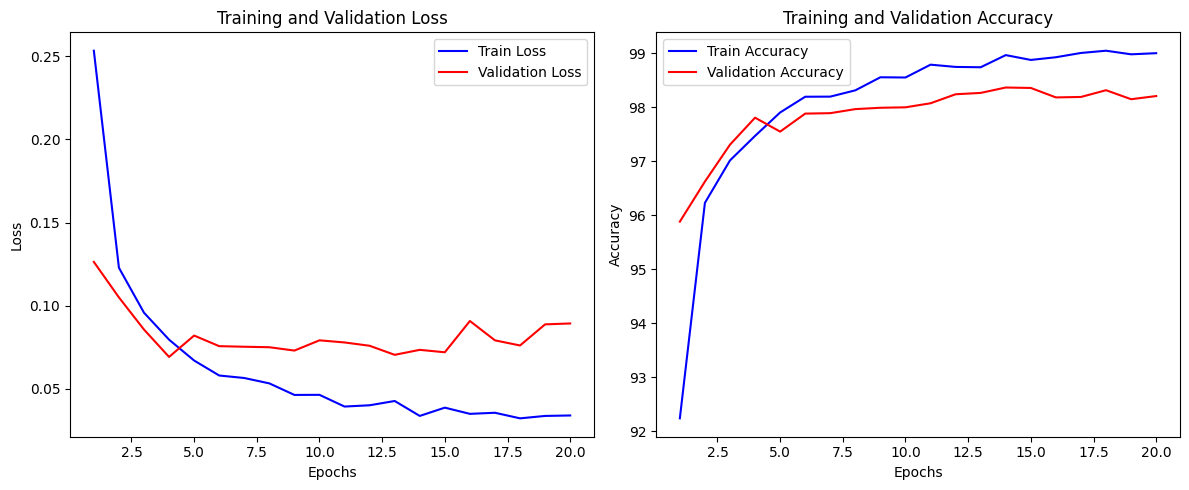

In [12]:
visualize_training_history(train_losses, train_accs, val_losses, val_accs)

In [13]:
class NetWithBN(nn.Module):

    def __init__(self):

        super(NetWithBN, self).__init__()

        self.fc1 = nn.Linear(784, 256)

        self.bn1 = nn.BatchNorm1d(256)

        self.fc2 = nn.Linear(256, 256)

        self.bn2 = nn.BatchNorm1d(256)

        self.fc3 = nn.Linear(256, 10)



    def forward(self, x):

        x = torch.relu(self.bn1(self.fc1(x)))

        x = torch.relu(self.bn2(self.fc2(x)))

        return self.fc3(x)

Epoch 0: Train Loss: 0.2162, Train Acc: 93.79%, Val Loss: 0.0940, Val Acc: 96.98%
Epoch 1: Train Loss: 0.0903, Train Acc: 97.27%, Val Loss: 0.0767, Val Acc: 97.53%
Epoch 2: Train Loss: 0.0635, Train Acc: 97.97%, Val Loss: 0.0703, Val Acc: 97.85%
Epoch 3: Train Loss: 0.0489, Train Acc: 98.42%, Val Loss: 0.0657, Val Acc: 97.90%
Epoch 4: Train Loss: 0.0401, Train Acc: 98.70%, Val Loss: 0.0602, Val Acc: 98.17%
Epoch 5: Train Loss: 0.0304, Train Acc: 98.99%, Val Loss: 0.0630, Val Acc: 98.05%
Epoch 6: Train Loss: 0.0289, Train Acc: 99.04%, Val Loss: 0.0585, Val Acc: 98.32%
Epoch 7: Train Loss: 0.0224, Train Acc: 99.22%, Val Loss: 0.0644, Val Acc: 98.10%
Epoch 8: Train Loss: 0.0206, Train Acc: 99.33%, Val Loss: 0.0650, Val Acc: 98.30%
Epoch 9: Train Loss: 0.0187, Train Acc: 99.36%, Val Loss: 0.0697, Val Acc: 98.06%
Epoch 10: Train Loss: 0.0208, Train Acc: 99.32%, Val Loss: 0.0634, Val Acc: 98.17%
Epoch 11: Train Loss: 0.0155, Train Acc: 99.49%, Val Loss: 0.0642, Val Acc: 98.31%
Epoch 12: Trai

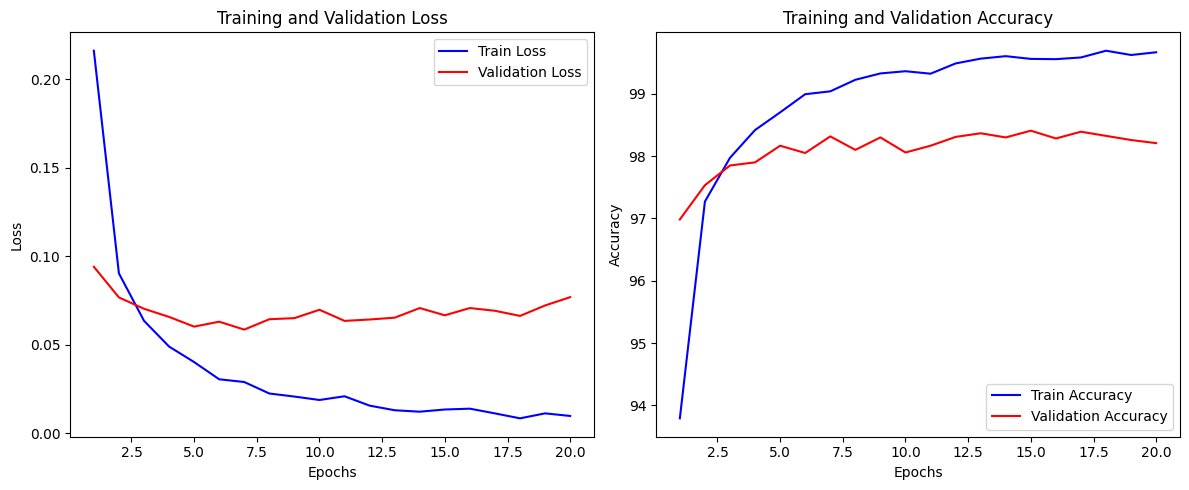

In [14]:
# BN



model = NetWithBN()

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters())



train_losses = []

train_accs = []

val_losses = []

val_accs = []



for epoch in range(20):

    model.train()

    train_loss = 0

    train_correct = 0

    train_total = 0

    for batch_idx, (data, target) in enumerate(train_loader):

        optimizer.zero_grad()

        output = model(data.view(data.size(0), -1))

        loss = criterion(output, target)

        loss.backward()

        optimizer.step()

        

        train_loss += loss.item()

        _, predicted = output.max(1)

        train_total += target.size(0)

        train_correct += predicted.eq(target).sum().item()

    

    train_loss /= len(train_loader)

    train_acc = 100. * train_correct / train_total

    

    model.eval()

    val_loss = 0

    val_correct = 0

    val_total = 0

    with torch.no_grad():

        for data, target in val_loader:

            output = model(data.view(data.size(0), -1))

            val_loss += criterion(output, target).item()

            _, predicted = output.max(1)

            val_total += target.size(0)

            val_correct += predicted.eq(target).sum().item()

    

    val_loss /= len(val_loader)

    val_acc = 100. * val_correct / val_total

    

    # save results

    train_losses.append(train_loss)

    train_accs.append(train_acc)

    val_losses.append(val_loss)

    val_accs.append(val_acc)

    

    print(f'Epoch {epoch}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, '

          f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

    

    

visualize_training_history(train_losses, train_accs, val_losses, val_accs)

# Hyperparameter optimization

In [15]:
import optuna

In [16]:
class Net(nn.Module):

    def __init__(self, dropout_rate, use_batchnorm):

        super(Net, self).__init__()

        self.fc1 = nn.Linear(784, 512)

        self.fc2 = nn.Linear(512, 512)

        self.fc3 = nn.Linear(512, 10)

        self.dropout = nn.Dropout(dropout_rate)

        self.use_batchnorm = use_batchnorm

        if use_batchnorm:

            self.bn1 = nn.BatchNorm1d(512)

            self.bn2 = nn.BatchNorm1d(512)



    def forward(self, x):

        x = x.view(-1, 784)

        x = self.fc1(x)

        if self.use_batchnorm:

            x = self.bn1(x)

        x = torch.relu(x)

        x = self.dropout(x)

        x = self.fc2(x)

        if self.use_batchnorm:

            x = self.bn2(x)

        x = torch.relu(x)

        x = self.dropout(x)

        return self.fc3(x)

In [17]:
def objective(trial):

    # determine hyperparameters for optimization

    lr = trial.suggest_float('lr', 1e-5, 1e-1, log=True)

    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)

    use_batchnorm = trial.suggest_categorical('use_batchnorm', [True, False])

    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128, 256])

    

    # create a model with selected hyperparameters

    model = Net(dropout_rate, use_batchnorm)

    

    # training settings

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    optimizer = optim.Adam(model.parameters(), lr=lr)

    criterion = nn.CrossEntropyLoss()

    

    # model training

    model.train()

    for epoch in range(10):  # let's limit it to 10 epochs for speed

        for batch_idx, (data, target) in enumerate(train_loader):

            optimizer.zero_grad()

            output = model(data)

            loss = criterion(output, target)

            loss.backward()

            optimizer.step()

        

        # Early stopping

        if epoch > 2 and loss.item() > prev_loss:

            break

        prev_loss = loss.item()

    

    # model evaluation

    model.eval()

    correct = 0

    total = 0

    with torch.no_grad():

        for data, target in DataLoader(test_dataset, batch_size=1000):

            output = model(data)

            _, predicted = torch.max(output.data, 1)

            total += target.size(0)

            correct += (predicted == target).sum().item()

    

    accuracy = correct / total

    return accuracy

In [18]:
study = optuna.create_study(direction='maximize')

study.optimize(objective, n_trials=100)



print('Number of finished trials:', len(study.trials))

print('Best trial:')

trial = study.best_trial

print('  Value: ', trial.value)

print('  Params: ')

for key, value in trial.params.items():

    print('    {}: {}'.format(key, value))

[I 2024-10-13 19:56:27,237] A new study created in memory with name: no-name-7d16940a-8d1c-47af-b19a-79b18cf3258d
[I 2024-10-13 19:57:39,887] Trial 0 finished with value: 0.9667 and parameters: {'lr': 0.002517587549194028, 'dropout_rate': 0.37437719947891135, 'use_batchnorm': False, 'batch_size': 64}. Best is trial 0 with value: 0.9667.
[I 2024-10-13 19:58:26,167] Trial 1 finished with value: 0.9794 and parameters: {'lr': 0.0015429667745501534, 'dropout_rate': 0.10928034099636529, 'use_batchnorm': True, 'batch_size': 256}. Best is trial 1 with value: 0.9794.
[I 2024-10-13 20:00:06,739] Trial 2 finished with value: 0.9737 and parameters: {'lr': 0.006483610270017627, 'dropout_rate': 0.36458917580139005, 'use_batchnorm': True, 'batch_size': 32}. Best is trial 1 with value: 0.9794.
[I 2024-10-13 20:01:07,169] Trial 3 finished with value: 0.9676 and parameters: {'lr': 0.0018889633831864323, 'dropout_rate': 0.293639024324034, 'use_batchnorm': False, 'batch_size': 128}. Best is trial 1 with v

Number of finished trials: 100
Best trial:
  Value:  0.9828
  Params: 
    lr: 0.0011154258651176847
    dropout_rate: 0.27721850073533344
    use_batchnorm: True
    batch_size: 32


/tmp/ipykernel_23/3129924123.py:5: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


<Figure size 1000x600 with 0 Axes>

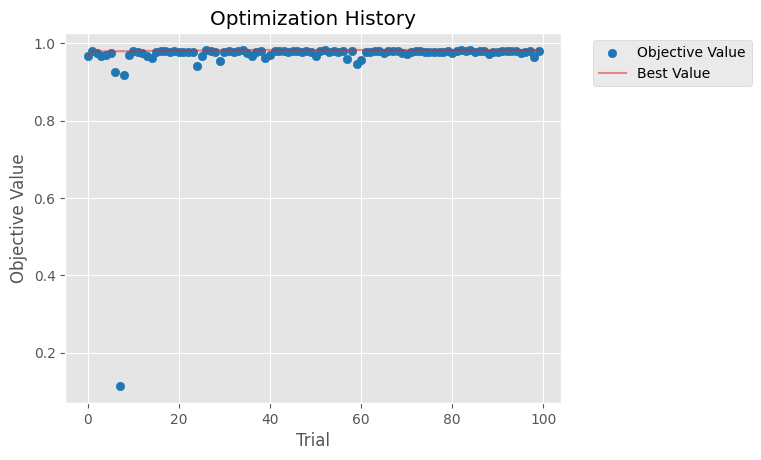

In [19]:
# 1. Optimization history plot

plt.figure(figsize=(10, 6))

optuna.visualization.matplotlib.plot_optimization_history(study)

plt.title("Optimization History")

plt.show()

/tmp/ipykernel_23/1239617777.py:5: ExperimentalWarning: plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


<Figure size 1000x600 with 0 Axes>

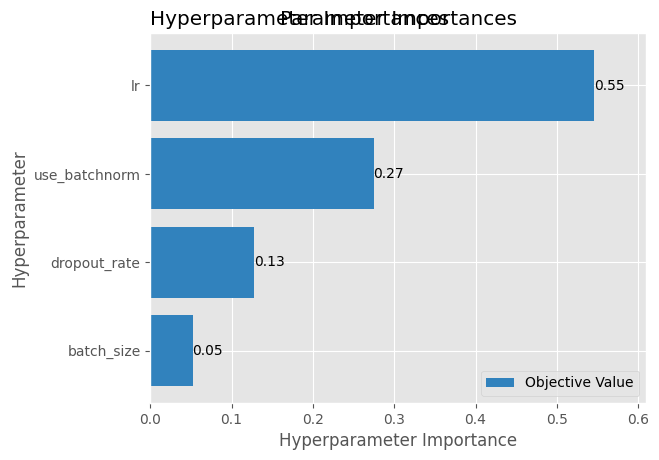

In [20]:
# 2. Parameter importance plot

plt.figure(figsize=(10, 6))

optuna.visualization.matplotlib.plot_param_importances(study)

plt.title("Parameter Importances")

plt.show()

/tmp/ipykernel_23/2741978070.py:5: ExperimentalWarning: plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_parallel_coordinate(study)


<Figure size 1000x600 with 0 Axes>

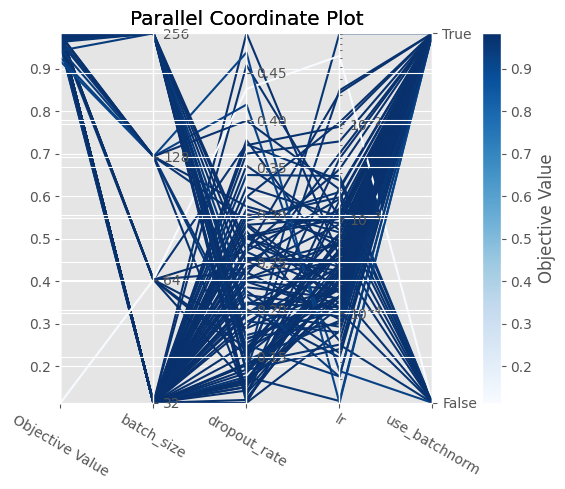

In [21]:
# 3. Parameters interaction plot

plt.figure(figsize=(10, 6))

optuna.visualization.matplotlib.plot_parallel_coordinate(study)

plt.title("Parallel Coordinate Plot")

plt.show()

/tmp/ipykernel_23/3520510973.py:5: ExperimentalWarning: plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_slice(study)


<Figure size 1000x600 with 0 Axes>

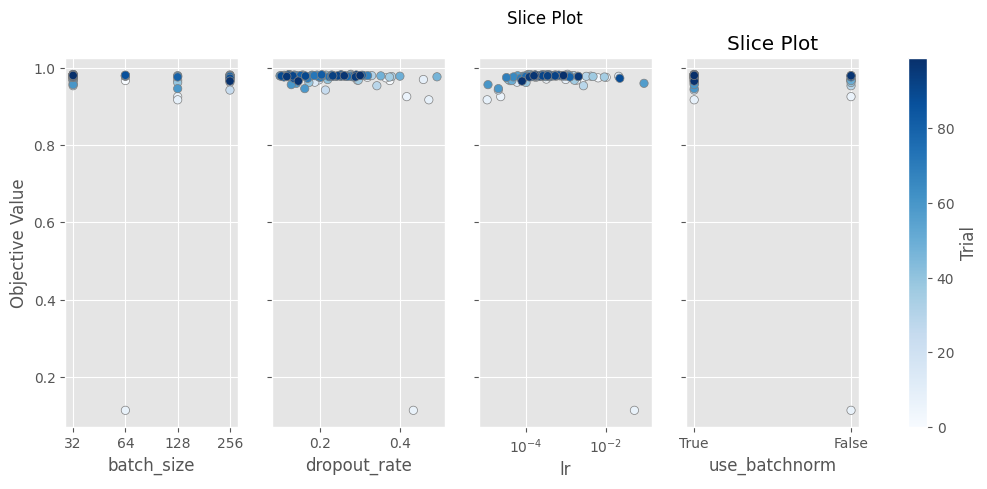

In [22]:
# 4. Parameter value distribution plot

plt.figure(figsize=(10, 6))

optuna.visualization.matplotlib.plot_slice(study)

plt.title("Slice Plot")

plt.show()

In [23]:
# 5. Interactive optimization plot

fig = optuna.visualization.plot_optimization_history(study)

fig.show()

In [24]:
# 6. Interactive parameter importance plot

fig = optuna.visualization.plot_param_importances(study)

fig.show()

In [25]:
# 7. Interactive interaction of parameters plot

fig = optuna.visualization.plot_parallel_coordinate(study)

fig.show()

In [26]:
# 8. Interactive parameter value distribution plot

fig = optuna.visualization.plot_slice(study)

fig.show()